In [1]:
#SHAP Analysis
import pandas as pd
import xgboost as xgb
import shap
import pickle
import matplotlib.pyplot as plt

In [2]:
with open("../outputs/xgboost_churn_model.pkl", "rb") as f:
    model = pickle.load(f)

df = pd.read_csv("../data/processed/features.csv")
X = df.drop(columns=['user_id', 'is_churn'])

Calculating SHAP values for a 5,000 user sample...
Rendering the SHAP Summary Plot...


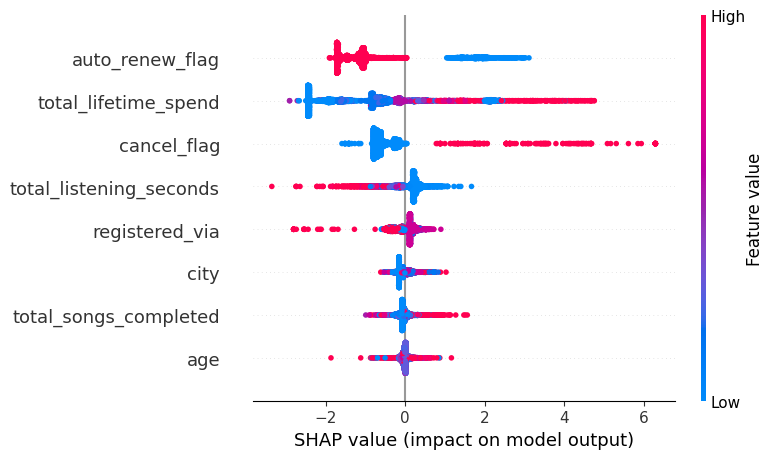

In [3]:
# SHAP math is insanely heavy. Running it on 860k rows would take hours.
# We take a representative random sample of 5,000 users to get the business insights in seconds.
print("Calculating SHAP values for a 5,000 user sample...")
X_sample = X.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print("Rendering the SHAP Summary Plot...")
# This will output a beautiful, colorful chart directly in your notebook
shap.summary_plot(shap_values, X_sample)